# Image Scene Classification of Multiclass

# Forkan Amin

Data Scientist

M.Sc. in Applied Statistics and Data Science, JU

B.sc. in Applied Mathematics, NSTU


In [1]:
# ============================================
# Intel Image Classification with ResNet18
# Complete Google Colab Project
# ============================================

# Step 1: Install required packages
!pip install kagglehub gradio -q

import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import zipfile
import shutil
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("✅ All imports successful!")

✅ All imports successful!


Mount Google Drive and Download Dataset

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Method 1: Download dataset directly from Kaggle (Fastest)
print("\n📥 Downloading dataset from Kaggle...")

try:
    import kagglehub
    dataset_path = kagglehub.dataset_download("puneet6060/intel-image-classification")
    print(f"✅ Dataset downloaded to: {dataset_path}")
except Exception as e:
    print(f"⚠️ Kagglehub failed: {e}")
    print("Downloading using wget...")

    # Alternative download method
    !wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=1dm1ZI4YRePh23B9THbV72fv6hpGfLqd8' -O dataset.zip

    # If wget fails, use manual upload
    if not os.path.exists("dataset.zip"):
        from google.colab import files
        print("\n📤 Please upload the intel-image-classification.zip file")
        uploaded = files.upload()
        for filename in uploaded.keys():
            if filename.endswith('.zip'):
                with zipfile.ZipFile(filename, 'r') as zip_ref:
                    zip_ref.extractall('./')
                dataset_path = "./intel-image-classification"
                break
    else:
        with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
            zip_ref.extractall('./')
        dataset_path = "./intel-image-classification"

print(f"📁 Dataset path: {dataset_path}")

# Find the correct structure
def find_dataset_dirs(base_path):
    """Find seg_train, seg_test, seg_pred directories."""
    train_dir = None
    test_dir = None
    pred_dir = None

    # Walk through the directory
    for root, dirs, files in os.walk(base_path):
        if "seg_train" in root:
            train_dir = root
            # Check if seg_train has class folders
            if train_dir:
                classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
                if not classes:
                    # Try one level deeper
                    for sub_dir in os.listdir(train_dir):
                        sub_path = os.path.join(train_dir, sub_dir)
                        if os.path.isdir(sub_path):
                            classes = [d for d in os.listdir(sub_path) if os.path.isdir(os.path.join(sub_path, d))]
                            if classes:
                                train_dir = sub_path
                                break
        if "seg_test" in root:
            test_dir = root
        if "seg_pred" in root:
            pred_dir = root

    return train_dir, test_dir, pred_dir

TRAIN_DIR, TEST_DIR, PREDICT_DIR = find_dataset_dirs(dataset_path)

# If not found, try common paths
if TRAIN_DIR is None:
    possible_paths = [
        "./intel-image-classification/seg_train/seg_train",
        "./seg_train/seg_train",
        "./seg_train",
        "./intel-image-classification/seg_train"
    ]
    for path in possible_paths:
        if os.path.exists(path):
            TRAIN_DIR = path
            break

print(f"\n📂 Training directory: {TRAIN_DIR}")
print(f"📂 Test directory: {TEST_DIR}")

Mounted at /content/drive

📥 Downloading dataset from Kaggle...
Using Colab cache for faster access to the 'intel-image-classification' dataset.
✅ Dataset downloaded to: /kaggle/input/intel-image-classification
📁 Dataset path: /kaggle/input/intel-image-classification

📂 Training directory: /kaggle/input/intel-image-classification/seg_train/seg_train/glacier
📂 Test directory: /kaggle/input/intel-image-classification/seg_test/seg_test/glacier


Prepare Data Loaders

In [4]:
import os

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🚀 Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Correct TRAIN_DIR and TEST_DIR if they are pointing to a single class folder
# Based on the typical structure: dataset_path/seg_train/seg_train/{classes}
# and the error message, TRAIN_DIR needs to be one level up.
# Example: /kaggle/input/intel-image-classification/seg_train/seg_train
if TRAIN_DIR.endswith('/glacier') or TRAIN_DIR.endswith('/buildings') or TRAIN_DIR.endswith('/forest') or TRAIN_DIR.endswith('/mountain') or TRAIN_DIR.endswith('/sea') or TRAIN_DIR.endswith('/street'):
    TRAIN_DIR = os.path.dirname(TRAIN_DIR)

if TEST_DIR and (TEST_DIR.endswith('/glacier') or TEST_DIR.endswith('/buildings') or TEST_DIR.endswith('/forest') or TEST_DIR.endswith('/mountain') or TEST_DIR.endswith('/sea') or TEST_DIR.endswith('/street')):
    TEST_DIR = os.path.dirname(TEST_DIR)

print(f"Updated Training directory: {TRAIN_DIR}")
print(f"Updated Test directory: {TEST_DIR}")

# Image preprocessing
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
print("\n📊 Loading datasets...")

full_train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
class_names = full_train_dataset.classes
num_classes = len(class_names)

print(f"   Classes: {class_names}")
print(f"   Total training images: {len(full_train_dataset)}")

# Split train/validation
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Load test dataset
if TEST_DIR and os.path.exists(TEST_DIR):
    test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=eval_transform)
    print(f"   Test images: {len(test_dataset)}")
else:
    test_dataset = None
    print("   ⚠️ Test dataset not found")

# Create data loaders
BATCH_SIZE = 64  # Larger batch for faster training

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

if test_dataset:
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=True
    )

print(f"\n✅ Data loaders ready!")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")


🚀 Device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB
Updated Training directory: /kaggle/input/intel-image-classification/seg_train/seg_train
Updated Test directory: /kaggle/input/intel-image-classification/seg_test/seg_test

📊 Loading datasets...
   Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
   Total training images: 14034
   Test images: 3000

✅ Data loaders ready!
   Training batches: 176
   Validation batches: 44


Visualize Sample Images

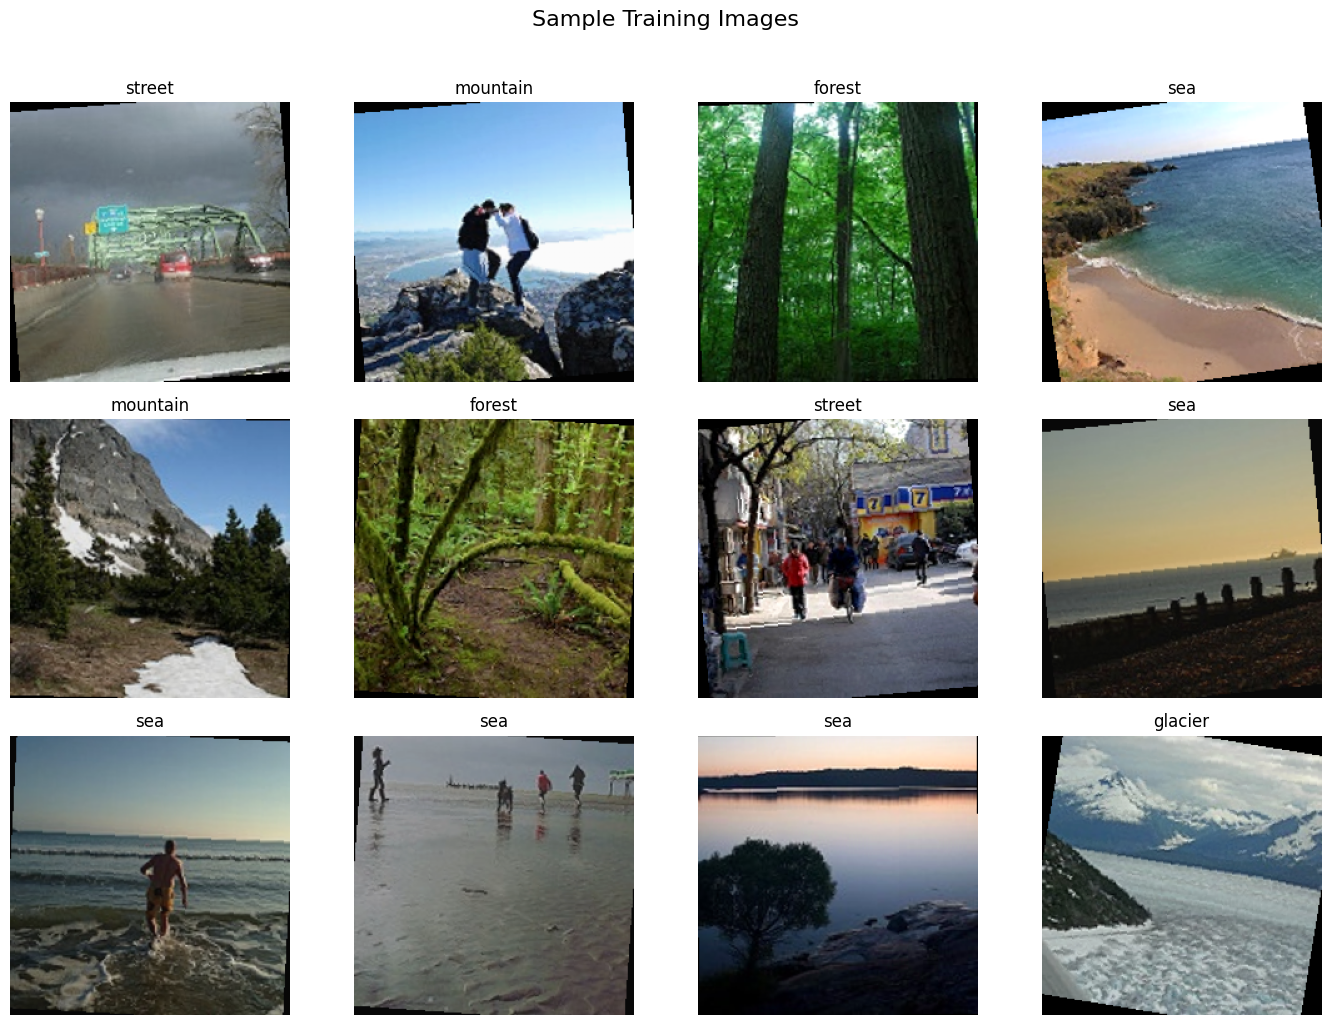

In [5]:
# Display sample images from the dataset
def denormalize(img):
    """Denormalize image for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    return torch.clamp(img, 0, 1)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

# Get a batch
images, labels = next(iter(train_loader))

for idx in range(12):
    img = denormalize(images[idx])
    img = img.permute(1, 2, 0).numpy()

    axes[idx].imshow(img)
    axes[idx].set_title(f"{class_names[labels[idx]]}", fontsize=12)
    axes[idx].axis('off')

plt.suptitle("Sample Training Images", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Build and Train Model

In [6]:
# Load pretrained ResNet18
print("\n Loading pretrained ResNet18...")
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

model = model.to(device)
print(f" Model ready! Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)

# Training functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / total, 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return total_loss / total, 100. * correct / total

# Training loop
EPOCHS = 5
print(f"\n🏋️ Starting training for {EPOCHS} epochs...")
print("="*60)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-"*40)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validate
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Learning rate scheduling
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/best_model.pth')
        print(" Best model saved!")

training_time = time.time() - start_time
print(f"\n Training complete in {training_time/60:.1f} minutes!")
print(f"Best validation accuracy: {best_val_acc:.2f}%")


 Loading pretrained ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]


 Model ready! Trainable parameters: 265,734

🏋️ Starting training for 5 epochs...

Epoch 1/5
----------------------------------------


Train Loss: 0.6919 | Train Acc: 73.24%
Val Loss:   0.3479 | Val Acc:   86.71%
 Best model saved!

Epoch 2/5
----------------------------------------


Train Loss: 0.5445 | Train Acc: 79.17%
Val Loss:   0.3407 | Val Acc:   87.74%
 Best model saved!

Epoch 3/5
----------------------------------------


Train Loss: 0.5026 | Train Acc: 80.97%
Val Loss:   0.3457 | Val Acc:   88.17%
 Best model saved!

Epoch 4/5
----------------------------------------


Train Loss: 0.5130 | Train Acc: 80.64%
Val Loss:   0.3245 | Val Acc:   88.49%
 Best model saved!

Epoch 5/5
----------------------------------------


Train Loss: 0.5018 | Train Acc: 81.26%
Val Loss:   0.3391 | Val Acc:   87.89%

 Training complete in 6.9 minutes!
Best validation accuracy: 88.49%


Plot Training Results

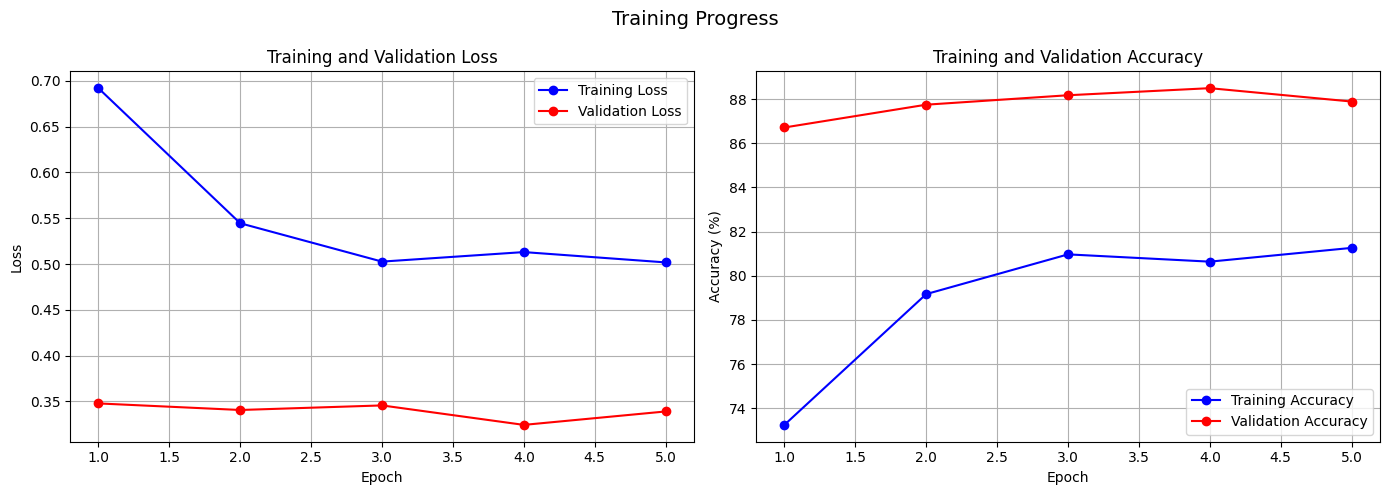

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(range(1, EPOCHS+1), train_losses, 'b-o', label='Training Loss')
ax1.plot(range(1, EPOCHS+1), val_losses, 'r-o', label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(range(1, EPOCHS+1), train_accs, 'b-o', label='Training Accuracy')
ax2.plot(range(1, EPOCHS+1), val_accs, 'r-o', label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.suptitle('Training Progress', fontsize=14)
plt.tight_layout()
plt.show()

Test the Model

 Best model loaded!



 Test Results:
   Test Loss: 0.3051
   Test Accuracy: 89.60%



 Classification Report:
              precision    recall  f1-score   support

   buildings       0.88      0.90      0.89       437
      forest       0.99      0.96      0.98       474
     glacier       0.89      0.80      0.84       553
    mountain       0.81      0.87      0.84       525
         sea       0.92      0.96      0.94       510
      street       0.90      0.90      0.90       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



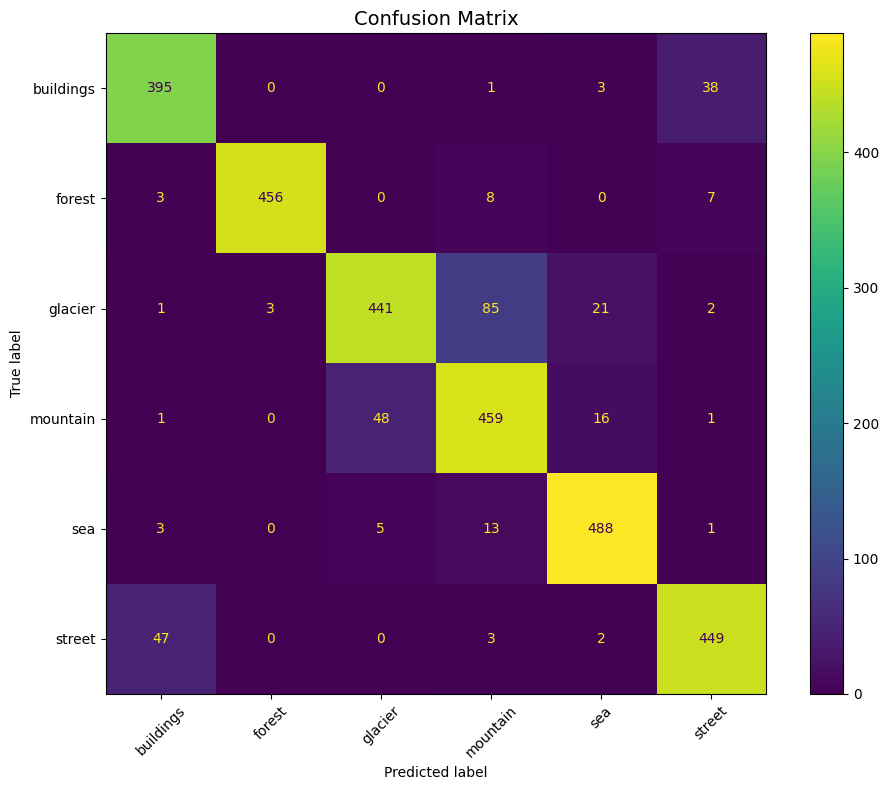

In [8]:
# Load best model
model.load_state_dict(torch.load('/content/best_model.pth'))
print(" Best model loaded!")

if test_dataset:
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"\n Test Results:")
    print(f"   Test Loss: {test_loss:.4f}")
    print(f"   Test Accuracy: {test_acc:.2f}%")
else:
    print("\n⚠️ No test dataset available.")

# Get predictions
if test_dataset:
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Classification report
    print("\n Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, xticks_rotation=45)
    plt.title('Confusion Matrix', fontsize=14)
    plt.tight_layout()
    plt.show()

Display Predictions on Test Images

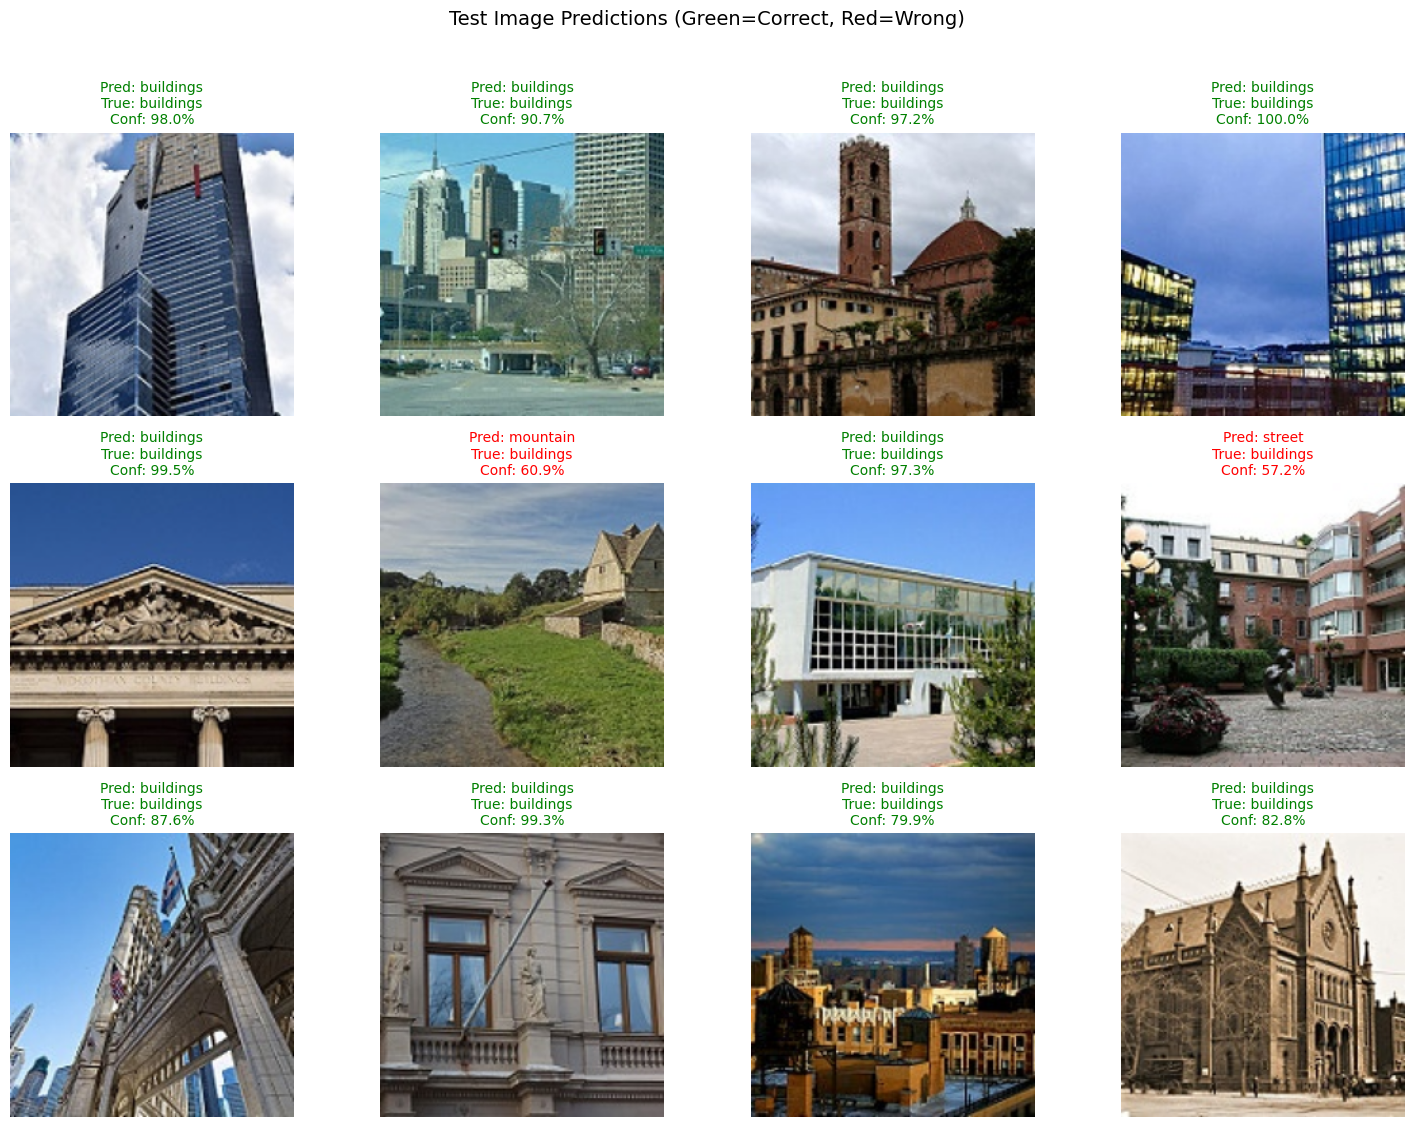

In [9]:
if test_dataset:
    # Get a batch of test images
    test_iter = iter(test_loader)
    test_images, test_labels = next(test_iter)
    test_images = test_images.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(test_images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)

    # Display predictions
    fig, axes = plt.subplots(3, 4, figsize=(15, 11))
    axes = axes.flatten()

    for idx in range(12):
        img = denormalize(test_images[idx].cpu())
        img = img.permute(1, 2, 0).numpy()

        pred_class = class_names[preds[idx].item()]
        true_class = class_names[test_labels[idx].item()]
        confidence = probs[idx][preds[idx]].item() * 100

        axes[idx].imshow(img)
        color = 'green' if preds[idx] == test_labels[idx] else 'red'
        axes[idx].set_title(f'Pred: {pred_class}\nTrue: {true_class}\nConf: {confidence:.1f}%',
                           color=color, fontsize=10)
        axes[idx].axis('off')

    plt.suptitle('Test Image Predictions (Green=Correct, Red=Wrong)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

Create Gradio Web Interface

In [10]:
!pip install gradio -q
import gradio as gr

def predict_image(image):
    """Predict the class of an uploaded image."""
    # Preprocess
    image = image.convert("RGB")
    image_tensor = eval_transform(image).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.softmax(outputs, dim=1)[0]

    # Return results
    results = {class_names[i]: float(probs[i]) for i in range(len(class_names))}
    return results

# Create interface with examples
interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label=" Upload an Image"),
    outputs=gr.Label(num_top_classes=3, label=" Top Predictions"),
    title=" Natural Scene Classifier",
    description="""
    ### Classify images into 6 categories:
    🏢 Buildings | 🌲 Forest | ❄️ Glacier | ⛰️ Mountain | 🌊 Sea | 🏙️ Street

    Upload any image to see the prediction!
    """,
    theme="soft",
    allow_flagging="never"
)

print("\n Launching Gradio Interface...")
interface.launch(share=True, debug=False)


 Launching Gradio Interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f612357ba0e5e3b56e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Batch Prediction and Analysis

In [11]:
def export_model_for_production(model, class_names, image_size):
    """Export model with preprocessing for production use."""
    import json
    import torch
    from torchvision import transforms
    from PIL import Image
    import numpy as np

    # Create wrapper class
    class SceneClassifier:
        def __init__(self, model_path, class_names, device='cpu', image_size=224):
            self.device = torch.device(device)
            self.class_names = class_names
            self.image_size = image_size

            # Load model
            checkpoint = torch.load(model_path, map_location=self.device)
            self.model = resnet18()
            self.model.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(self.model.fc.in_features, 512),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(512, len(class_names))
            )
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.model = self.model.to(self.device)
            self.model.eval()

            # Preprocessing
            self.transform = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])

        def predict(self, image):
            """Predict single image."""
            if isinstance(image, str):
                image = Image.open(image).convert("RGB")
            elif isinstance(image, np.ndarray):
                image = Image.fromarray(image).convert("RGB")

            img_tensor = self.transform(image).unsqueeze(0).to(self.device)

            with torch.no_grad():
                outputs = self.model(img_tensor)
                probs = torch.softmax(outputs, dim=1)[0]
                _, predicted = outputs.max(1)

            return {
                'prediction': self.class_names[predicted.item()],
                'confidence': probs[predicted.item()].item(),
                'probabilities': {
                    self.class_names[i]: probs[i].item()
                    for i in range(len(self.class_names))
                }
            }

        def predict_batch(self, images):
            """Predict multiple images."""
            results = []
            for img in images:
                results.append(self.predict(img))
            return results

    # Save wrapper with metadata
    metadata = {
        'class_names': class_names,
        'num_classes': len(class_names),
        'image_size': image_size,
        'model_name': 'resnet18',
        'created_date': time.strftime('%Y-%m-%d %H:%M:%S')
    }

    with open('/content/model_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)

    # Export to TorchScript for production
    model.eval()
    example_input = torch.randn(1, 3, image_size, image_size).to(device)
    traced_model = torch.jit.trace(model, example_input)
    traced_model.save('/content/model_scripted.pt')

    print(" Production-ready model exported!")
    print("   - model_scripted.pt: TorchScript model")
    print("   - model_metadata.json: Model metadata")
    print("   - SceneClassifier: Python wrapper class")

# Export model
print("\n📦 Exporting model for production...")
export_model_for_production(model, class_names, IMAGE_SIZE)


📦 Exporting model for production...
 Production-ready model exported!
   - model_scripted.pt: TorchScript model
   - model_metadata.json: Model metadata
   - SceneClassifier: Python wrapper class


Test Individual Image with Confidence Visualization


 Testing image: 6234.jpg


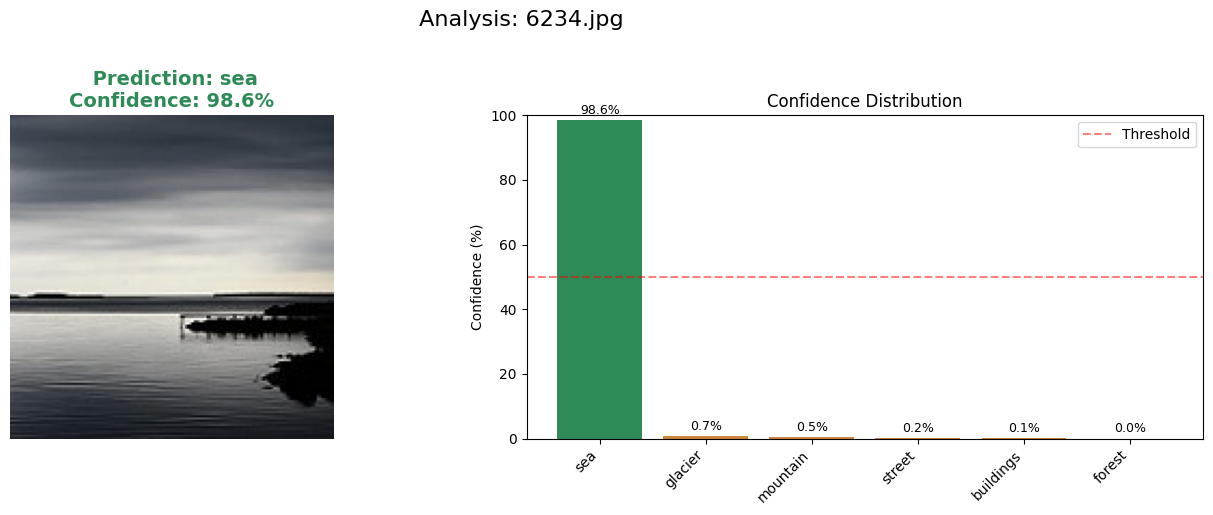


✅ All finishing tasks complete!


In [12]:
def predict_single_image(image_path, return_details=False):
    """Test a single image and show detailed results."""
    # Load image
    img = Image.open(image_path).convert("RGB")
    img_tensor = eval_transform(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        _, predicted = outputs.max(1)

    # Results
    pred_class = class_names[predicted.item()]
    confidence = probs[predicted.item()].item() * 100

    # Detailed visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Image with prediction
    axes[0].imshow(img)
    axes[0].set_title(f" Prediction: {pred_class}\nConfidence: {confidence:.1f}%",
                     fontsize=14, fontweight='bold', color='#2E8B57')
    axes[0].axis('off')

    # Probability distribution
    sorted_idx = np.argsort(probs.cpu().numpy())[::-1]
    sorted_probs = probs.cpu().numpy()[sorted_idx] * 100
    sorted_classes = [class_names[i] for i in sorted_idx]

    bars = axes[1].bar(range(len(sorted_classes)), sorted_probs,
                      color=['#2E8B57' if i == 0 else '#CD853F' for i in range(len(sorted_classes))])
    axes[1].set_xticks(range(len(sorted_classes)))
    axes[1].set_xticklabels(sorted_classes, rotation=45, ha='right')
    axes[1].set_ylabel('Confidence (%)')
    axes[1].set_title('Confidence Distribution')
    axes[1].set_ylim(0, 100)
    axes[1].axhline(y=50, color='r', linestyle='--', alpha=0.5, label='Threshold')
    axes[1].legend()

    # Add value labels
    for bar, prob in zip(bars, sorted_probs):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{prob:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.suptitle(f' Analysis: {os.path.basename(image_path)}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    if return_details:
        return {
            'prediction': pred_class,
            'confidence': confidence,
            'probabilities': {class_names[i]: probs[i].item() * 100 for i in range(len(class_names))}
        }

# Test with an image from the prediction folder
if PREDICT_DIR and os.path.exists(PREDICT_DIR):
    pred_files = [f for f in os.listdir(PREDICT_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]
    if pred_files:
        test_img = os.path.join(PREDICT_DIR, pred_files[0])
        print(f"\n Testing image: {pred_files[0]}")
        predict_single_image(test_img)

print("\n✅ All finishing tasks complete!")